# <span style="color:green"> Numerical Simulation Laboratory (NSL) </span>

## IMPORTANT: Guidelines for a proper conduct of the exercises
1. you should create code that is correct, simple, well organized, indented, commented, which uses self-explanatory names for variables and that is numerically efficient.
2. I expect a responsible interaction during the exercises: the questions should be more related to the conduction of the exercises and to the meaning of the results obtained than to the computational problems. Bugs are usual in coding; for this reason, sooner or later, one should learn to deal with them by oneself ... if you'll be able to, it will be your main achievement in this Laboratory!

## <span style="color:blue">  Numerical exercises 1</span>

##  **Submission** 


### **Exercise 01.1 - Statistics** 

1. $\langle r \rangle = \int_0^1 r dr = 1/2$. 
2. $\sigma^2 = \int_0^1 (r-1/2)^2 dr = 1/12$.

<font color="red">Make a picture of the estimation of $\sigma^2$ and its uncertainty (which corresponds to Standard Deviation of the mean for the estimation of $\langle (r-1/2)^2 \rangle$) with a large number of *throws* $M$ (e.g. $M\ge 10^4$) as a function of the number of blocks, $N$</font> 

#### **Data Blocking**
To understand and appreciate the following plots, it is important to first understand what data blocking is.

Data blocking is a technique used to correctly estimate statistical uncertainty in the presence of autocorrelated data. The data is autocorrelated since RNG (random number generators) follow a deterministic rule starting from an initial seed. Let $M$ be the total number of values calculated in a Monte Carlo simulation and $N \in \mathbb{N}$ ($N < M$) be the number of blocks into which the data is divided. The goal is to calculate the progressive average value and its associated error by increasing the number of blocks considered in calculating the average, up to computing the final results for the entire dataset.

Each block contains $L = M/N$ steps, which are averaged to obtain an estimate of the observable for that specific block: $x_i$ with $i = 1, \dots, N$. Thanks to the linearity of the expectation value, the average of the entire dataset is simply equal to the average of these $N$ block averages. Most importantly, if the block size $L$ is large enough, the "memory" of the simulation decays, and the block averages $x_i$ become statistically independent. Due to the fact that datablocking with large enough blocks reduces to 0 the autocorrelation between data, then the Central Limit Theorem can be applied (which is satisfied only with uncorrelated data), and the statistical uncertainty associated with the mean value correctly follows a $1/\sqrt{N}$ trend.
$$ \langle x^2 \rangle \simeq \frac{1}{N} \sum_{i=1}^N x^2_i \quad \quad \langle x\rangle^2 \simeq \left( \frac{1}{N} \sum_{i=1}^N x_i \right)^2 $$
and therefore (from the definition of standard deviation of the average value):
$$ \frac{\sigma}{\sqrt{N-1}} \simeq \sqrt{\frac{1}{N-1} \left[ \frac{1}{N} \sum_{i=1}^N x^2_i - \left( \frac{1}{N} \sum_{i=1}^N x_i \right)^2 \right]} $$

#### <u> **Solution** </u>
#### **Mean and Variance of a uniform distribution**
To tackle this exercise I calculated $10^4$ random numbers distributed uniformly $[0,1)$ and to analize the data I used 100 blocks. Therefore, in the code $ M= 10000$ (number of data) and $N = 100$ (number of blocks) (these parameters will remain unchanged for the rest of the excercise of this jupyter notebook). The integral requested corresponds to the definition of calculating the average value of an evenly distributed variable in the interval $[0; 1)$, or as we studied in the theorical lessons, the first moment of the random variable $r$ chosen from a uniform random distribution.

\begin{equation}
    \int_{\mathbb{R}} r p(r) \,dr \implies \langle r \rangle = \int_0^1 r \,dr
    \tag{1}
\end{equation}

The second integral is the calculation of the variance, or the **central nth moment** with $n = 2$: 
\begin{equation}
    \sigma^2 = \int_0^1 (r-0.5)^2 \,dr
    \tag{2}
\end{equation}
To calculate the value of this integral I calculated $M$ times the value of $(r-0.5)^2$ with $r$ uniformly distributed in the interval $[0; 1)$ and then I calculated the average value of this quantity, using the **data blocking method** to estimate the uncertainty of the result and to calculate the average value of the integral. The results are shown in the following figures.

#### **Code snipet**
Code for the `int main()`
```cpp
int main(int argc, char *argv[])
{
   // --------- Excercise 1.1.1 ----------

   Random rnd{};
   init_gen(rnd);

   // number of random variables found
   const int M = 100000;
   // number of blocks
   const int N = 100;
   // Number of variables per block
   int L = (M / N);

   // vector with numbers from [0,1)
   vector<double> r{};

   // we are calculating the definition of average value from 0 to 1
   // with uniform distribution from 0 to 1
   Fill_Casual(r, rnd, M);
   datablocking(M, L, N, r, "../DATA/Data1.1.1.dat");

   // --------- Excercise 1.1.2 ----------

   r.clear();

   for (int i = 0; i < M; i++)
   {
      r.push_back(pow(rnd.Rannyu() - 0.5, 2));
   }
   rnd.SaveSeed();

   datablocking(M, L, N, r, "../DATA/Data1.1.2.dat");
   datablocking(M, int(M/N), N, r, "../DATA/db_try.dat");
//...
   
```
Code for the function `Fill_Casual(r, rnd, M)`:

```cpp
// Fill a vector with M numbers each found randomly in [0; 1)
void Fill_Casual(vector<double> &r, Random &rnd, const int &M)
{
   for (int i = 0; i < M; i++)
   {
      r.push_back(rnd.Rannyu());
   }
   rnd.SaveSeed();
}
```




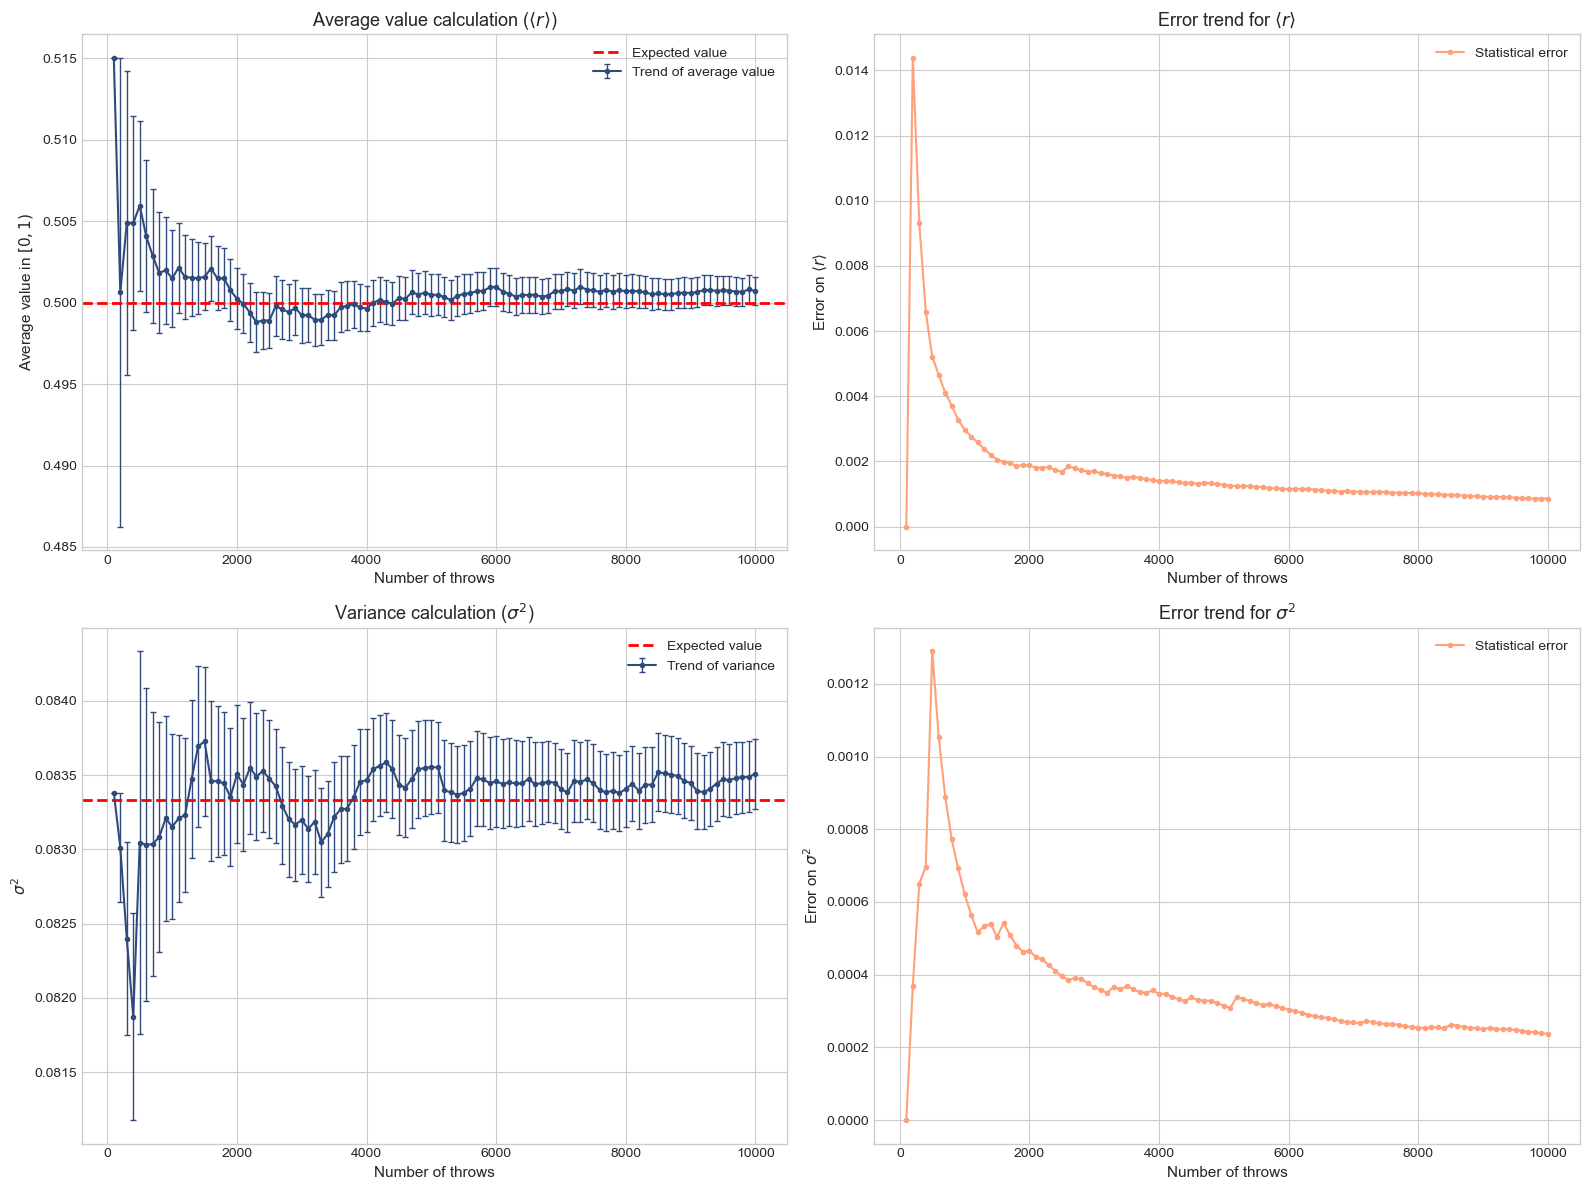

In [21]:
import numpy as np
import matplotlib.pyplot as plt


x1, f1, error1_data = np.loadtxt(
    "ES1.1/DATA/Data1.1.1.dat",
    usecols=(0, 1, 2),
    delimiter='\t',
    unpack=True
)
L = 100
x1 = x1 * L


x2, f2, error2_data = np.loadtxt(
    "ES1.1/DATA/Data1.1.2.dat",
    usecols=(0, 1, 2),
    delimiter='\t',
    unpack=True
)
x2 = x2 * L


plt.style.use('seaborn-v0_8-whitegrid')
fig, axs = plt.subplots(2, 2, figsize=(16, 12))


axs[0, 0].errorbar(
    x1, f1, yerr=error1_data,
    fmt='o-', markersize=3,
    capsize=2, elinewidth=1,
    label='Trend of average value',
    color='#2F4B7C'
)
axs[0, 0].axhline(
    y=0.5, color='red', linestyle='--', linewidth=2,
    label='Expected value'
)
axs[0, 0].set_xlabel('Number of throws', fontsize=11)
axs[0, 0].set_ylabel('Average value in $[0,1)$', fontsize=11)
axs[0, 0].set_title(r'Average value calculation ($\langle r \rangle$)', fontsize=13)
axs[0, 0].legend(fontsize=10)

axs[0, 1].plot(
    x1, error1_data,
    marker='o', markersize=3, linestyle='-',
    color='#FFA07A', label='Statistical error'
)
axs[0, 1].set_xlabel('Number of throws', fontsize=11)
axs[0, 1].set_ylabel(r'Error on $\langle r \rangle$', fontsize=11)
axs[0, 1].set_title(r'Error trend for $\langle r \rangle$', fontsize=13)
axs[0, 1].legend(fontsize=10)

axs[1, 0].errorbar(
    x2, f2, yerr=error2_data,
    fmt='o-', markersize=3,
    capsize=2, elinewidth=1,
    label='Trend of variance',
    color='#2F4B7C'
)
axs[1, 0].axhline(
    y=1.0/12.0, color='red', linestyle='--', linewidth=2,
    label='Expected value'
)
axs[1, 0].set_xlabel('Number of throws', fontsize=11)
axs[1, 0].set_ylabel('$\sigma^2$', fontsize=11)
axs[1, 0].set_title('Variance calculation ($\sigma^2$)', fontsize=13)
axs[1, 0].legend(fontsize=10)

axs[1, 1].plot(
    x2, error2_data,
    marker='o', markersize=3, linestyle='-',
    color='#FFA07A', label='Statistical error'
)
axs[1, 1].set_xlabel('Number of throws', fontsize=11)
axs[1, 1].set_ylabel('Error on $\sigma^2$', fontsize=11)
axs[1, 1].set_title('Error trend for $\sigma^2$', fontsize=13)
axs[1, 1].legend(fontsize=10)


plt.tight_layout()
plt.savefig("ES1.1/IMAGES/combined_results_and_errors.jpg", dpi=300)
plt.show()

On the left are displayed the plots of the averages computed using the **data blocking** method with their respective statistical uncertainties, while on the right are displayed the trends of the errors associated to the cumulative averages. It is possible to observe the $1/\sqrt{N}$ behaviour of the CLT.


#### **$\chi^2$**
The hypothesis is that the numbers $r$ are drawn from a uniform distribution. In Statistics we cannot prove that some random events are drawn from a particular distribution (Note, in fact, that such hypothesis is false: pseudo-random numbers are drawn from a deterministic algorithm!); we can try to estimate the probability that $r$ **are not** drawn from a uniform distribution. If this probability is low, we can safely reject this last hypothesis. To quantify this hypothesis it is useful to rely on the **chi-square** distribution. 
The definition of the chi-square distribution is the following:
\begin{equation}
    \chi^2 = \sum_{i=0}^{M} \frac{(O_i - E_i)^2}{\sigma^2}
    \tag{3}
\end{equation}
$\chi^2$ therefore is the sum of the squared differences between the observed and expected values normalised by the squared error assosciated to the observed variable. The probability to find $k$ items after a number of $n$ trials (with a probability $p$ to find that item in that specific interval) is given exactly by the Binomial Distribution. Given that this is the Binomial Distribution:
\begin{equation}
Pr(X=k) = {{n}\choose{k}} p^k (1-p)^{n-k} = \frac{n!}{k! (n-k)!} p^k (1-p)^{n-k}
\tag{4}
\end{equation}
The average of the Binomial distribution is $\langle X \rangle = np$, the variance is: $\sigma^2 = np (1-p)$. Thus if $p$ is small (since the number of intervals in which the entire set is divided is great) we have that $\sigma^2 \simeq np$, that is $\sigma^2 \simeq \langle X \rangle$ and this demonstrates why the denominator $E_i$ in $\chi^2$


3. Divide $[0,1]$ into $M$ identical sub-intervals and implement the $\chi^2$ test.

#### <u> **Solution** </u>
To tackle exercise 3, the first thing I defined were the following parameters: 
   - $N_{trials}$ = 100, 1000 as requested by the exercise
   - $N_{blocks}$ = 100 (number of bins to sample $\Chi^2$)
   - $M$ = 10000 (number of random numbers calculated in the interval $[0,1]$).

   $E_i$ in this case is - since the random numbers are sampled from a uniform distribution - equal to $n_{tot}p = n_{tot} / M$. I calculated $\chi^2_i$ for $i = 1, \dots, N_{trials}$ by generating $n_{tot}$ random numbers, dividing the interval into $M$ equal, consecutive, and disjoint sub-intervals, and summing over all of them. In this case the chi-square statistic is:
\begin{equation}
\chi^2 = \sum_{i=1}^M \frac{\left( n_i - n/M \right)^2}{n/M}
\tag{5}
\end{equation}



#### **Code snippet**
In `ES1.1/funzioni.h` can be found the following code which serves to sample an array of $\Chi^2$ values. This code calculates for `n_trials` the amount of numbers that can be found in each bin and, after having done so, executes the $\Chi^2$ values. The function `count_interval` serves in counting the number of numbers in the interval `h` dependent on the number of bins (the numbers are sampled $\in [0;1)$:
```c++
//-------------- Chi-test -------------
void Chi_test(Random &rnd, vector<double> &Chi_value, int n_trials)
{
   // Parameters for Chi-function
   const int N_blocks = 100;              // number of blocks
   const double h = 1.0 / 100.0;          // length of the block
   const int N_of_random_numbers = 10000; // Number of random numbers per vector
   double expected = (double)N_of_random_numbers / (double)N_blocks;

   vector<double> random_number; // random number vector
   double sum_for_Chi = 0;
   for (int j = 0; j < n_trials; j++)
   {
      random_number.clear();
      Fill_Casual(random_number, rnd, N_of_random_numbers);
      sum_for_Chi = 0;
      for (int i = 0; i < N_blocks; i++)
      {
         sum_for_Chi += pow(count_interval(h, i, random_number) - expected, 2) / expected;      
      }
      Chi_value.push_back(sum_for_Chi);
   }
}
```

Mean of Chi-square values for N_trials = 100: 100.68
Standard Deviation of Chi-square values for N_trials = 100: 11.80
Mean of Chi-square values for N_trials = 1000: 98.81
Standard Deviation of Chi-square values for N_trials = 1000: 14.06


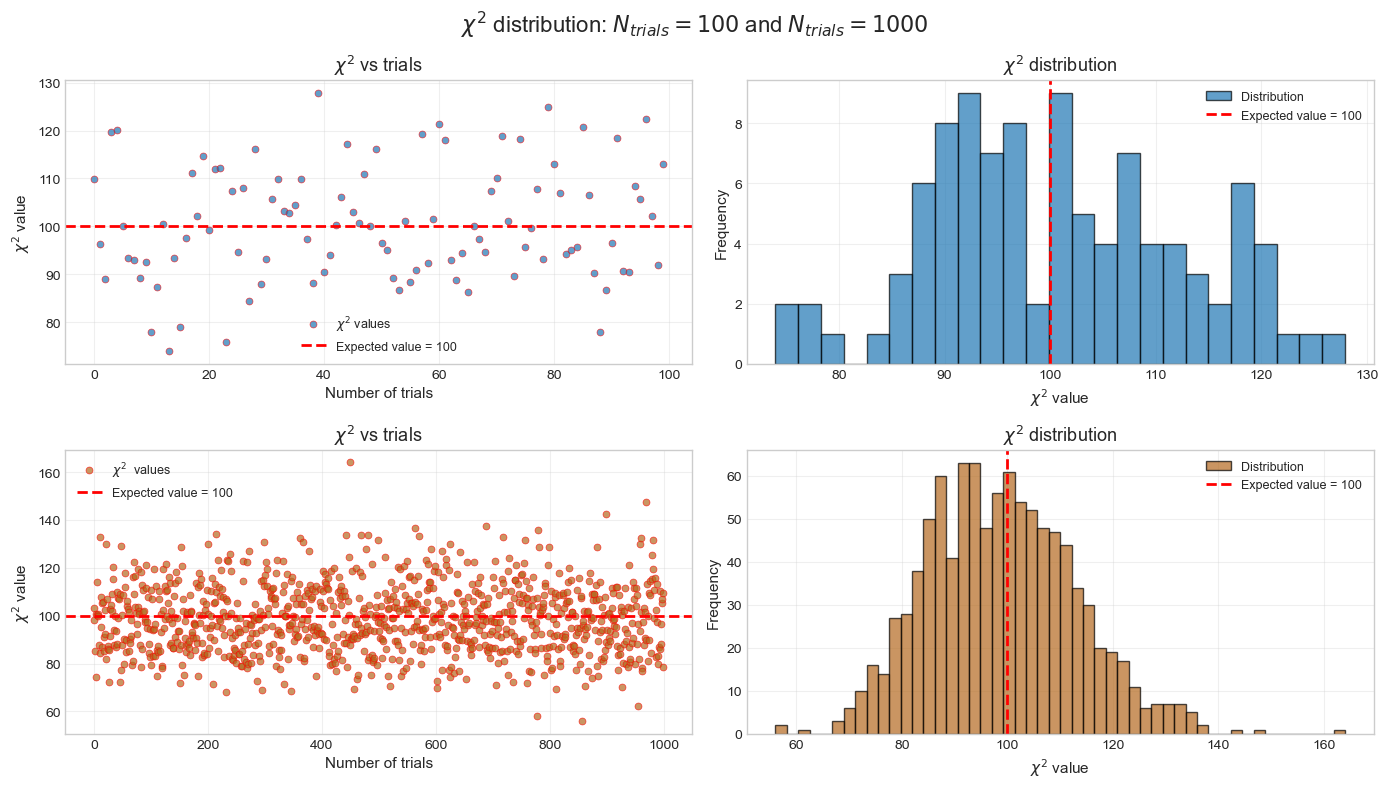

In [ ]:
x, f = np.loadtxt("ES1.1/DATA/Chivalue.dat",
                  usecols=(0,1),
                  delimiter='\t',
                  unpack=True)

fig, axs = plt.subplots(2, 2, figsize=(14, 8))
plt.suptitle("$\chi^2$ distribution: $N_{trials} = 100$ and $N_{trials} = 1000$", fontsize=16)


# --- Scatter plot ---
axs[0,0].plot(
    x, f,
    'o',
    linestyle='None',
    markersize=5,
    markerfacecolor='#1f77b4',
    markeredgecolor='red',
    markeredgewidth=0.5,
    alpha=0.7,
    label='$\chi^2$ values'
)

axs[0,0].axhline(
    y=100,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Expected value = 100'
)

axs[0,0].set_xlabel('Number of trials', fontsize=11)
axs[0,0].set_ylabel(r'$\chi^2$ value', fontsize=11)
axs[0,0].set_title(r'$\chi^2$ vs trials', fontsize=13)
axs[0,0].legend(fontsize=9)
axs[0,0].grid(alpha=0.3)


# --- Histogram ---
axs[0,1].hist(
    f,
    bins=25,
    color='#1f77b4',
    edgecolor='black',
    alpha=0.7,
    label='Distribution'
)

mean = np.mean(f)
std_dev = np.std(f)
print(f"Mean of Chi-square values for N_trials = 100: {mean:.2f}")
print(f"Standard Deviation of Chi-square values for N_trials = 100: {std_dev:.2f}")

axs[0,1].axvline(
    100,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Expected value = 100'
)

axs[0,1].set_xlabel(r'$\chi^2$ value', fontsize=11)
axs[0,1].set_ylabel('Frequency', fontsize=11)
axs[0,1].set_title(r'$\chi^2$ distribution', fontsize=13)
axs[0,1].legend(fontsize=9)
axs[0,1].grid(alpha=0.3)


x, f = np.loadtxt("ES1.1/DATA/Chivalue_more.dat",
                  usecols=(0,1),
                  delimiter='\t',
                  unpack=True)


# --- Scatter plot ---
axs[1,0].plot(
    x, f,
    'o',
    linestyle='None',
    markersize=5,
    markerfacecolor="#b4691f",
    markeredgecolor='red',
    markeredgewidth=0.5,
    alpha=0.7,
    label='$\chi^2$  values'
)

axs[1,0].axhline(
    y=100,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Expected value = 100'
)

axs[1,0].set_xlabel('Number of trials', fontsize=11)
axs[1,0].set_ylabel(r'$\chi^2$ value', fontsize=11)
axs[1,0].set_title(r'$\chi^2$ vs trials', fontsize=13)
axs[1,0].legend(fontsize=9)
axs[1,0].grid(alpha=0.3)


# --- Histogram ---

axs[1,1].hist(
    f,
    bins=50,
    color="#b4691f",
    edgecolor='black',
    alpha=0.7,
    label='Distribution'
)

axs[1,1].axvline(
    100,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Expected value = 100'
)

axs[1,1].set_xlabel(r'$\chi^2$ value', fontsize=11)
axs[1,1].set_ylabel('Frequency', fontsize=11)
axs[1,1].set_title(r'$\chi^2$ distribution', fontsize=13)
axs[1,1].legend(fontsize=9)
axs[1,1].grid(alpha=0.3)

mean = np.mean(f)
std_dev = np.std(f)
print(f"Mean of Chi-square values for N_trials = 1000: {mean:.2f}")
print(f"Standard Deviation of Chi-square values for N_trials = 1000: {std_dev:.2f}")

plt.tight_layout()
plt.savefig("ES1.1/IMAGES/Chi_Histo&Scatter.jpg", dpi=300)
plt.show()



From the plots we can clearly see that for greater number of $N_{trials}$ (= 1000) that the Central Limit Theorem is verified and that the mean value is around the expected value. Having plotted the the histogram for the $\chi^2$ values I decided to use the Kolmogorov–Smirnov test to verify the goodness of the distribution just found, since the K-S test quantifies the distance between an empirical distribution function and a cumulative theorical distribution function (the cumulative distribution $F(x)$ is the integral of the probability densitiy function $p(x)$ from -$\infty$ to x of a certain probability density, more on K-S test can be found here: [Kolmogorov–Smirnov test](https://en.wikipedia.org/wiki/Kolmogorov–Smirnov_test)). We want to put to the test how well cumulative distribution of the data set of the calculated $\Chi^2$ values is similar to that of a Gaussian probability density function with 100 degrees of freeedom.

--- KS Test for N_trials = 100 ---
KS Statistic: 0.1078, p-value: 0.1819
Result: We cannot reject the null hypothesis.

--- KS Test for N_trials = 1000 ---
KS Statistic: 0.0474, p-value: 0.0218
Result: We reject the null hypothesis.


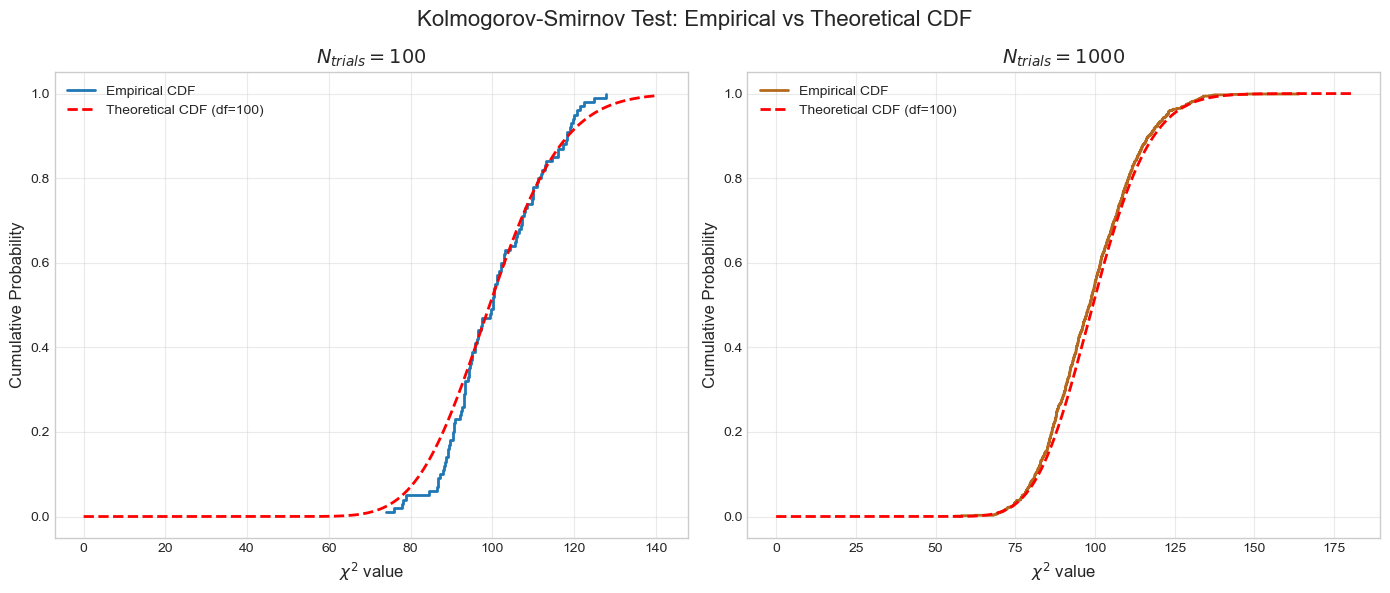

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, kstest


_, f1 = np.loadtxt("ES1.1/DATA/Chivalue.dat", usecols=(0,1), delimiter='\t', unpack=True)
_, f2 = np.loadtxt("ES1.1/DATA/Chivalue_more.dat", usecols=(0,1), delimiter='\t', unpack=True)

df_theoretical = 100  # Gradi di libertà teorici (M = 100 sotto-intervalli)

fig, axs = plt.subplots(1, 2, figsize=(14, 6), tight_layout=True)
fig.suptitle("Kolmogorov-Smirnov Test: Empirical vs Theoretical CDF", fontsize=16)


ks_stat1, p_value1 = kstest(f1, lambda x: chi2.cdf(x, df_theoretical))
print("--- KS Test for N_trials = 100 ---")
print(f"KS Statistic: {ks_stat1:.4f}, p-value: {p_value1:.4f}")
if p_value1 > 0.05:
    print("Result: We cannot reject the null hypothesis.")
else:
    print("Result: We reject the null hypothesis.")

# Calcolo CDF empirica
sorted_f1 = np.sort(f1)
empirical_cdf1 = np.arange(1, len(sorted_f1) + 1) / len(sorted_f1)

# Asse x per la curva teorica
x_pdf1 = np.linspace(0, max(f1)*1.1, 1000)

axs[0].step(sorted_f1, empirical_cdf1, where='post', label='Empirical CDF', color='#1f77b4', linewidth=2)
axs[0].plot(x_pdf1, chi2.cdf(x_pdf1, df_theoretical), color='red', linestyle='--', linewidth=2, label=f'Theoretical CDF (df={df_theoretical})')
axs[0].set_xlabel('$\chi^2$ value', fontsize=12)
axs[0].set_ylabel('Cumulative Probability', fontsize=12)
axs[0].set_title('$N_{trials} = 100$', fontsize=14)
axs[0].legend(fontsize=10)
axs[0].grid(alpha=0.4)

# ==========================================
# TEST KS PER N = 1000 (Grafico a destra)
# ==========================================
ks_stat2, p_value2 = kstest(f2, lambda x: chi2.cdf(x, df_theoretical))
print("\n--- KS Test for N_trials = 1000 ---")
print(f"KS Statistic: {ks_stat2:.4f}, p-value: {p_value2:.4f}")
if p_value2 > 0.05:
    print("Result: We cannot reject the null hypothesis.")
else:
    print("Result: We reject the null hypothesis.")

# Calcolo CDF empirica
sorted_f2 = np.sort(f2)
empirical_cdf2 = np.arange(1, len(sorted_f2) + 1) / len(sorted_f2)

# Asse x per la curva teorica
x_pdf2 = np.linspace(0, max(f2)*1.1, 1000)

axs[1].step(sorted_f2, empirical_cdf2, where='post', label='Empirical CDF', color='#b4691f', linewidth=2)
axs[1].plot(x_pdf2, chi2.cdf(x_pdf2, df_theoretical), color='red', linestyle='--', linewidth=2, label=f'Theoretical CDF (df={df_theoretical})')
axs[1].set_xlabel('$\chi^2$ value', fontsize=12)
axs[1].set_ylabel('Cumulative Probability', fontsize=12)
axs[1].set_title('$N_{trials} = 1000$', fontsize=14)
axs[1].legend(fontsize=10)
axs[1].grid(alpha=0.4)

# Salvataggio e visualizzazione
plt.savefig("ES1.1/IMAGES/Chi_KS_Test.jpg", dpi=300)
plt.show()

Despite the plot on the right seemingly being more corresponding to the theoretical CDF its p-value is lower and as a result the null hypothesis for $N_{trials}$ = 1000 must be rejected, this is due to the fact that the p-test for $N_{trials}$ becomes more severe.

### **ES 1.2 - Verify CLT**
- Extend Pseudo-Random Number generator downloaded from the NSL Ariel web site and check the Central Limit Theorem:
1. Add two probability distributions by using the **method of the inversion of the cumulative distribution** to sample from a **generic** <font color="red">exponential distribution</font>, $p(x) = \lambda \exp(-\lambda x)$, $x\in [0;+\infty]$ (see <a href="https://en.wikipedia.org/wiki/Exponential_distribution">this Wikipedia link</a>), and a **generic** <font color="red">Cauchy-Lorentz distribution</font> $p(x)=\frac{1}{\pi}\frac{\Gamma}{(x-\mu)^2+\Gamma^2}$, $x\in [-\infty;+\infty]$ (see <a href="https://en.wikipedia.org/wiki/Cauchy_distribution">this Wikipedia link</a>).
2. <font color="red">Make 3 pictures</font> with the histograms obtained filling them with $10^4$ realizations of $S_N = \frac{1}{N}\sum_{i=1}^N x_i$ (for $N=1, 2, 10, 100$), being $x_i$ a random variable sampled throwing a *standard* dice (fig.1), an *exponential* dice (fig.2, use $\lambda=1$) and a *Lorentzian* dice (fig.3, use $\mu=0$ and $\Gamma=1$).

Note that you can try to fit the case $N=100$ with a Gaussian for standard and exponential dices, whereas you should use a Cauchy-Lorentz distribution for the last case.

#### <u> **Solution** </u>
1. As a hypothesis for the **method of the inversion of the cumulative distribution** is to work with cumulative functions that are analically invertible (as the name says). The method works in the following way: a number $y$ $\in$ $[0;1]$ is sampled **uniformly**, this corresponds to the **image** of the function $F(x)$. We decide to sample $y$ uniformly from that interval due to a clear mathematical reason that is the following (it is important to remember that $y$ = $y(x)$):
\begin{equation}
    p_y(y) = p_x(x)(\frac{dy}{dx})^{-1} = p_x(x)(\frac{dF(x)}{dx})^{-1} = 1
    \tag{6}
\end{equation}
As demonstrated the probability density associated to the image of the cumulative probability is uniform in $[0;1]$ since that is where the image is defined.
Now we use that:
\begin{equation}
    x = F^{-1}_x(y)
    \tag{7}
\end{equation}
Using the analitically inverted cumulative function it is possible to find the exact value of the variable $x$ that is random variable sampled from the probability density $p(x)$ with
\begin{equation}
    p(x) = \frac{dF(x)}{dx}
    \tag{8}
\end{equation}

The inverted CDFs:
* For the exponential distribution:

  $$y = -\frac{\ln(1 - p)}{\lambda}$$

We could sample $ln(p)$ but the RNG generates number $\in [0;1)$ which could cause problems if 0 were to be sampled.

* For the Cauchy-Lorentz distribution:

  $$y = \mu + \gamma \tan \left[ \pi \left( p - \frac{1}{2} \right) \right]$$


#### **Code snipet**
In `ES1.2/random.cpp` can be found the implemented following codes

```cpp
double Random ::Exp(double lambda)
{
   // This function generates a random number from an exponential distribution
   return (-1.0 / lambda) * log(1.0 - Rannyu());
}

double Random ::Cauchy_Lorentz(double gamma, double mu)
{
   // This function generates a random number from an Cauchy-Lorentian distribution
   return mu + gamma * tan(M_PI * (Rannyu() - 0.5));
}
```
2. Below are shown histograms obtained filling them with $N_{values} = 10^4$ realizations of $S_N = \frac{1}{N}\sum_{i=1}^N x_i$ (for $N=1, 2, 10, 100$), being $x_i$ a random variable sampled throwing a *standard* dice, an *exponential* dice ($\lambda=1$) and a *Lorentzian* dice ($\mu=0$ and $\Gamma=1$).


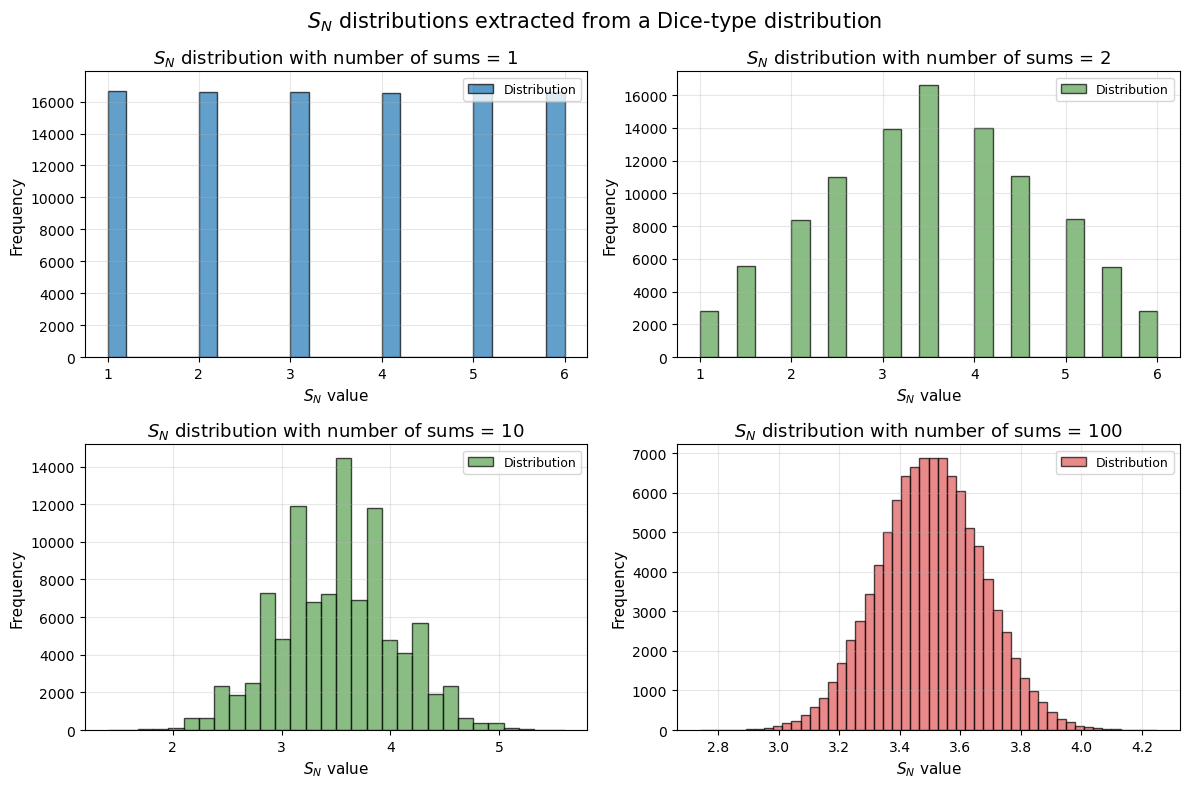

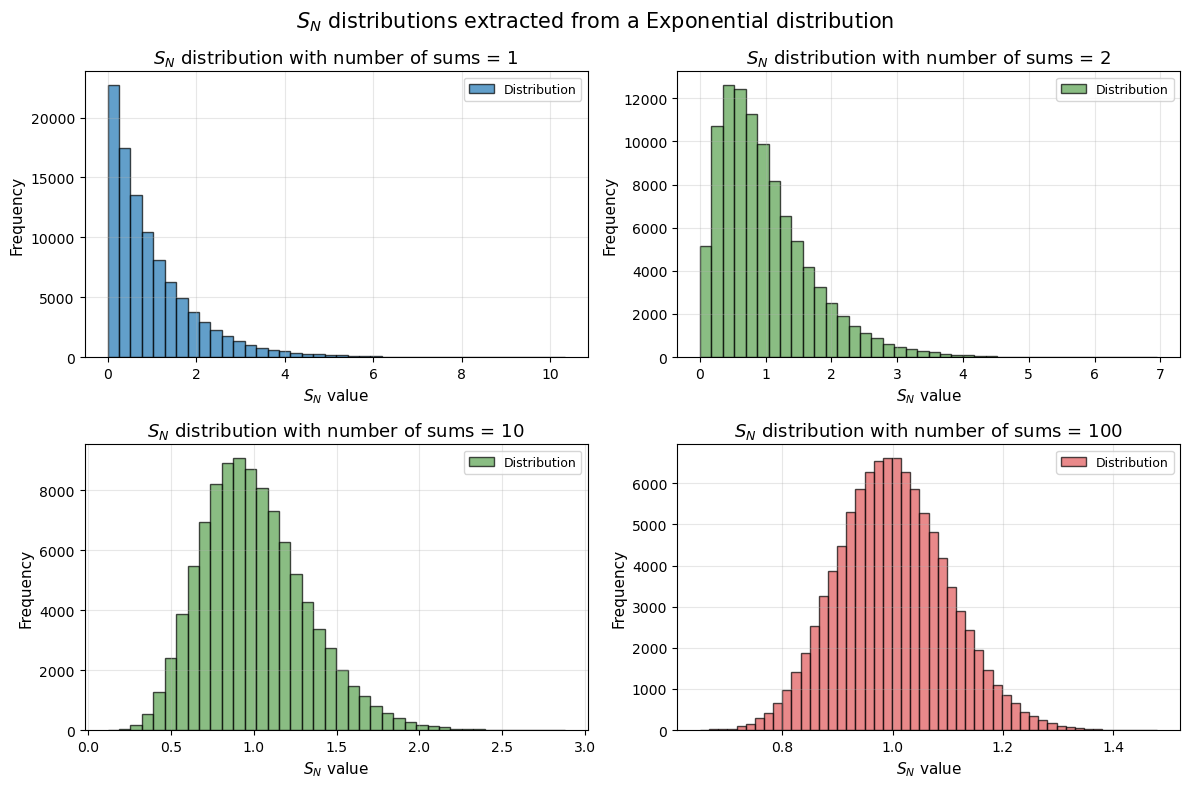

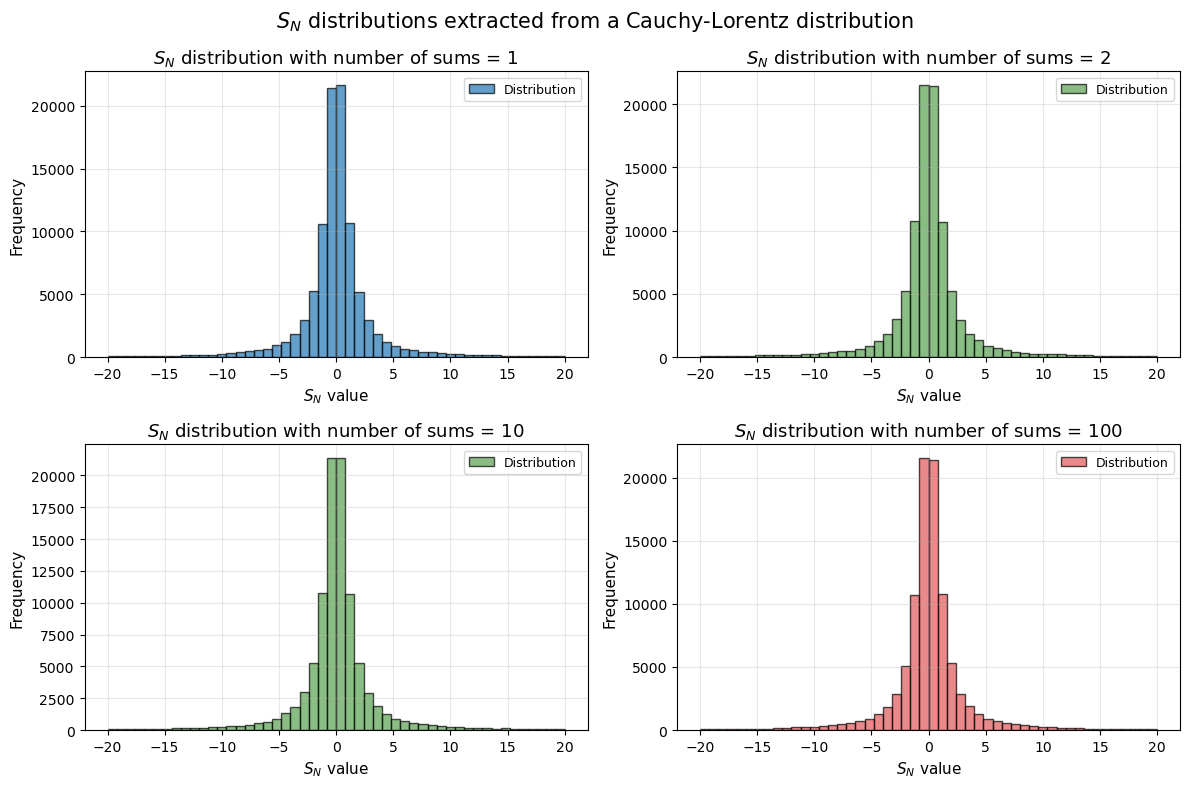

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_sn_distributions(dist_name, file_prefix, bins_list, x_range=None):
    """
    Funzione per creare la griglia 2x2 di istogrammi per i diversi valori di N (1, 2, 10, 100).
    """
    n_values = [1, 2, 10, 100]
    colors = ['#1f77b4', '#59A14F', '#59A14F', '#E15759']
    
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    plt.suptitle(rf"$S_N$ distributions extracted from a {dist_name} distribution", fontsize=15)
    
    for idx, n in enumerate(n_values):
        row = idx // 2
        col = idx % 2
        ax = axs[row, col]
        
        file_path = f"ES1.2/DATA/{file_prefix}{n}.dat"
        
        try:
            f = np.loadtxt(file_path, usecols=(0), delimiter='\t', unpack=True)
        except FileNotFoundError:
            print(f"Warning: File {file_path} not found.")
            continue

        # Configurazione degli argomenti per l'istogramma
        hist_kwargs = {
            'bins': bins_list[idx],
            'color': colors[idx],
            'edgecolor': 'black',
            'alpha': 0.7,
            'label': 'Distribution'
        }
        
        if x_range is not None:
            hist_kwargs['range'] = x_range

        # --- Histogram ---
        ax.hist(f, **hist_kwargs)

        ax.set_xlabel(r'$S_N$ value', fontsize=11)
        ax.set_ylabel('Frequency', fontsize=11)
        ax.set_title(rf'$S_N$ distribution with number of sums = {n}', fontsize=13)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

    # Creazione della cartella IMAGES se non esiste
    os.makedirs("ES1.2/IMAGES", exist_ok=True)
    
    plt.tight_layout()
    output_filename = f"ES1.2/IMAGES/{file_prefix}_distributions.jpg"
    plt.savefig(output_filename, dpi=300)
    plt.show()


plot_sn_distributions(
    dist_name="Dice-type", 
    file_prefix="Dice", 
    bins_list=[25, 25, 30, 50]
)

plot_sn_distributions(
    dist_name="Exponential", 
    file_prefix="Exponential", 
    bins_list=[40, 40, 40, 50]
)

plot_sn_distributions(
    dist_name="Cauchy-Lorentz", 
    file_prefix="Lorentian", 
    bins_list=[50, 50, 50, 50], 
    x_range=(-20, 20)
)




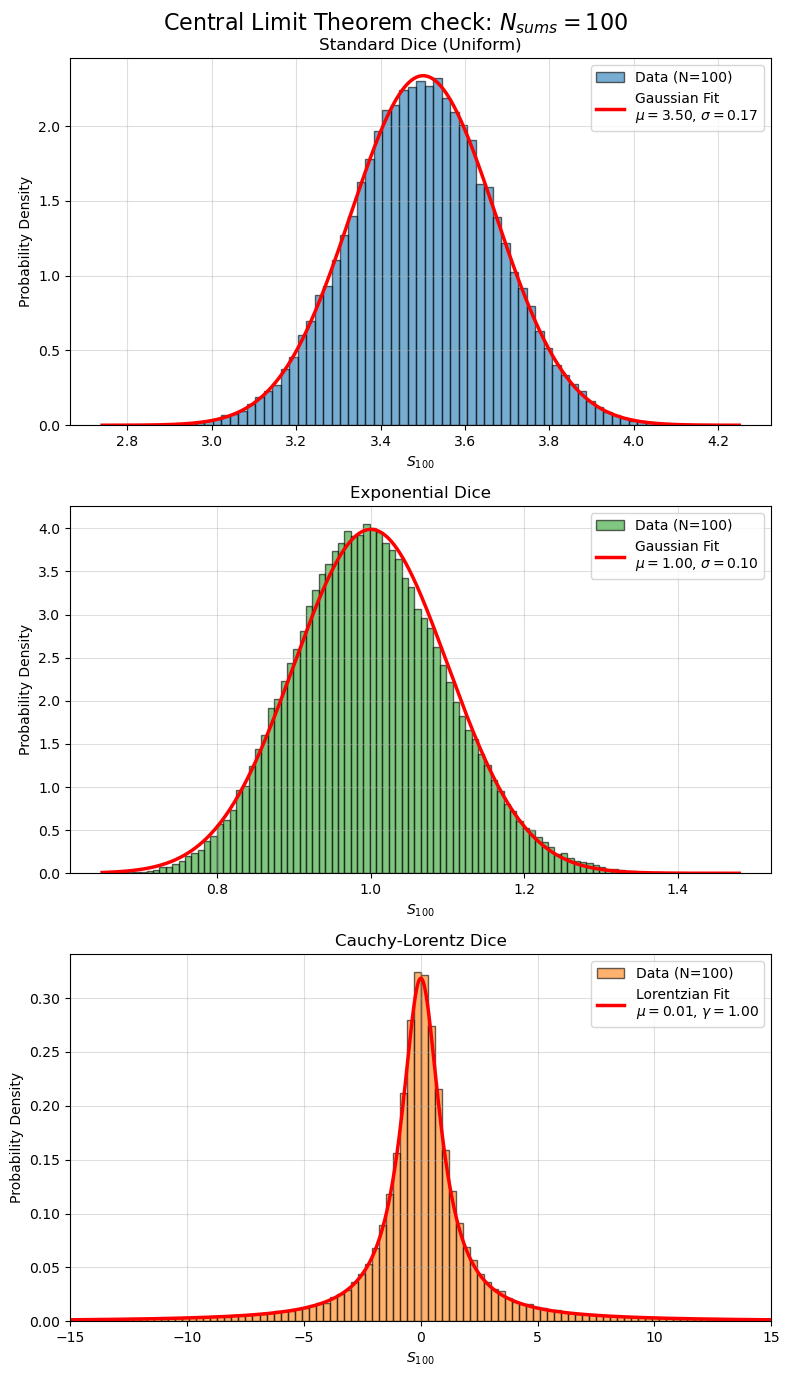

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, cauchy

# ==========================================
# 1. Caricamento Dati
# ==========================================
# NOTA: Sostituisci i percorsi con quelli dei tuoi file generati dal C++.
# Qui assumo che tu stia estraendo solo la colonna o il file relativo a N=100.
data_unif = np.loadtxt("ES1.2/DATA/Dice100.dat", unpack=True)
data_exp = np.loadtxt("ES1.2/DATA/Exponential100.dat", unpack=True)
data_cauchy = np.loadtxt("ES1.2/DATA/Lorentian100.dat", unpack=True)

# ==========================================
# 2. Setup della Figura (3 righe, 1 colonna)
# ==========================================
fig, axs = plt.subplots(3, 1, figsize=(8, 14), tight_layout=True)
fig.suptitle("Central Limit Theorem check: $N_{sums} = 100$", fontsize=16)

# ==========================================
# GRAFICO 1: Dado Uniforme (Fit Gaussiano)
# ==========================================
# fit gaussiano restituisce media (mu) e deviazione standard (std)
mu_unif, std_unif = norm.fit(data_unif)

axs[0].hist(data_unif, bins=75, density=True, color='#1f77b4', edgecolor='black', alpha=0.6, label='Data (N=100)')
x_unif = np.linspace(min(data_unif), max(data_unif), 1000)
axs[0].plot(x_unif, norm.pdf(x_unif, mu_unif, std_unif), 'r-', lw=2.5, 
            label=f'Gaussian Fit\n$\mu={mu_unif:.2f}$, $\sigma={std_unif:.2f}$')

axs[0].set_title('Standard Dice (Uniform)')
axs[0].set_xlabel('$S_{100}$')
axs[0].set_ylabel('Probability Density')
axs[0].legend()
axs[0].grid(alpha=0.4)

# ==========================================
# GRAFICO 2: Dado Esponenziale (Fit Gaussiano)
# ==========================================
# Anche se i dati di partenza erano esponenziali, la somma deve fittare una Gaussiana!
mu_exp, std_exp = norm.fit(data_exp)

axs[1].hist(data_exp, bins=100, density=True, color='#2ca02c', edgecolor='black', alpha=0.6, label='Data (N=100)')
x_exp = np.linspace(min(data_exp), max(data_exp), 1000)
axs[1].plot(x_exp, norm.pdf(x_exp, mu_exp, std_exp), 'r-', lw=2.5, 
            label=f'Gaussian Fit\n$\mu={mu_exp:.2f}$, $\sigma={std_exp:.2f}$')

axs[1].set_title('Exponential Dice')
axs[1].set_xlabel('$S_{100}$')
axs[1].set_ylabel('Probability Density')
axs[1].legend()
axs[1].grid(alpha=0.4)

# ==========================================
# GRAFICO 3: Dado Cauchy-Lorentz (Fit Lorentziano)
# ==========================================
# Per la Cauchy il CLT non vale. La somma di Cauchy è una Cauchy.
loc_cauchy, scale_cauchy = cauchy.fit(data_cauchy)

# IMPORTANTE: limitiamo il range di plot per colpa delle code grasse!
plot_range = (-15, 15)
axs[2].hist(data_cauchy, bins=100, range=plot_range, density=True, color='#ff7f0e', edgecolor='black', alpha=0.6, label='Data (N=100)')
x_cauchy = np.linspace(plot_range[0], plot_range[1], 1000)
axs[2].plot(x_cauchy, cauchy.pdf(x_cauchy, loc_cauchy, scale_cauchy), 'r-', lw=2.5, 
            label=f'Lorentzian Fit\n$\mu={loc_cauchy:.2f}$, $\gamma={scale_cauchy:.2f}$')

axs[2].set_title('Cauchy-Lorentz Dice')
axs[2].set_xlabel('$S_{100}$')
axs[2].set_ylabel('Probability Density')
axs[2].set_xlim(plot_range) # Tagliamo le ascisse per non far esplodere il grafico
axs[2].legend()
axs[2].grid(alpha=0.4)

# Salvataggio e visualizzazione
plt.savefig("ES1.2/IMAGES/Fits_N100.jpg", dpi=300)
plt.show()

#### **Comment**
The graphs produced clearly show how the sum of independent random variables follows a Gaussian distribution. Let us state briefly what the Central Limit Theorem is:
We consider $N$ statistically independent and identically distributed random variables $x_1, \dots, x_N$, i.e.,
  $$p_N(x_1, x_2, \dots, x_N) = p(x_1)p(x_2)\dots p(x_N)$$

  we require $\langle x_1 \rangle = \dots = \langle x_N \rangle = \mu$

  Furthermore, let us denote $\langle x_1^2 \rangle - \langle x_1 \rangle^2 = \dots = \langle x_N^2 \rangle - \langle x_N \rangle^2 = \sigma^2 < \infty$

  What is the pdf of $A_N = \frac{1}{N} \sum_{n=1}^N x_n$ $\left( S_N = \sum_{n=1}^N x_n \right)$ ?

  It follows that:

  1) $\langle A_N \rangle = \mu \quad \left( \langle S_N \rangle = \mu N \right)$

  2) $\sigma_{A_N}^2 = \frac{\sigma^2}{N} \quad \left( \sigma_{S_N}^2 = N\sigma^2 \right)$

  3) $$p_N(A_N) \xrightarrow{N\to\infty} \frac{1}{\sqrt{2\pi\sigma_{A_N}^2}} \exp\left[ - \frac{(A_N - \mu)^2}{2\sigma_{A_N}^2} \right]$$

   $$ \left( p_N(S_N) \xrightarrow{N\to\infty} \frac{1}{\sqrt{2\pi\sigma_{S_N}^2}} \exp\left[ - \frac{(S_N - \mu N)^2}{2\sigma_{S_N}^2} \right] \right) $$

From the two Gaussian fits we clearly see the CLT in action, however from the third one we see that the average sum of Lorentian-sampled values doesn't follow a Gaussian distribution, this is because the Lorentian doesn't have a defined variance nor mean, this can be seen clearly by trying to analitically calculate the value of the variance for the Cauchy-Lorentz distribution since for large values of $x$ (integration variable) we integrate a constant on an infinite domain (more info can be found here: <a href="https://en.wikipedia.org/wiki/Cauchy_distribution">CLT Distribution</a>).

### <u> **Es 1.3 - Buffon** </u>

* **Simulate** the Buffon's experiment (see LSN_Lecture_00, supplementary material): A needle of length $L$ is thrown at random onto a horizontal plane ruled with straight lines a distance $d$ (must be $d > L$, but do not use $d \gg L$ otherwise $P \ll 1$) apart. The probability $P$ that the needle will intersect one of these lines is: $P = 2L/\pi d$. This could be used to evaluate $\pi$ from throws of the needle: if the needle is thrown down $N_{thr}$ times and is observed to land on a line $N_{hit}$ of those times, we can make an estimate of $\pi$ from

  $$\pi = \frac{2L}{Pd} = \lim_{N_{thr} \to \infty}\frac{2LN_{thr}}{N_{hit}d}$$

  <span style="color:red">Make a picture of the estimation of $\pi$ and its uncertainty (Standard Deviation of the mean) with a large number of *throws* $M$ as a function of the number of blocks, $N$ (see below: Computing statistical uncertainties). If possible, do not use $\pi$ to evaluate $\pi$.</span>

#### <u> **Solution** </u>

#### **Code snippet**
The following code shows how the `int main()` is written and the two main functions that I wrote for this exercise: `bool NeedleThrow` and `double experiment`. To write the code I create `struct Needle` which contains the ($x$, $y$) coordinates of the head of the needle and the $x$ coordinate of the tail of the needle. In the code the length of the needle = 1 and the distance between to lines = 20.
```cpp
//----------- Exercises 1.2 -----------
int main(int argc, char *argv[])
{
   // --------- Excercise 1.2 ----------
   Random rnd{};
   inizializza_generatore_random(rnd);

   // -------- Parameters for experiment -------
   int N_tries = 10000; //10^4
   int N_experiments = 100000; //10^5

   // -------- Parameters for data blocking ------
   int N_blocks = 100;
   int L = int(N_experiments/N_blocks);

   double d = 20; // Length between two lines
   vector<double> hit_values;
   for (int i = 0; i < N_experiments; i++)
   {
      hit_values.push_back(experiment(N_tries, rnd, d));
      cout << "Experiment n " << i + 1 << endl;
   }

   // Ora passiamo N_tries e d per calcolare pi greco dentro la funzione
   datablocking(N_experiments,L, N_blocks, pi_values, "../DATA/Buffon_20.dat");

   return 0;
}

// function returns true if the line was touched by the needle and false if the line wasn't
bool NeedleThrow(Random &rand, double &d)
{
   Needle trial;
   bool check = false;

   trial.x_centre = rand.Rannyu(0.0, d);
   
   double norm2;
   do {
       trial.x = rand.Rannyu(-1.0, 1.0);
       trial.y = rand.Rannyu(-1.0, 1.0);
       norm2 = trial.x * trial.x + trial.y * trial.y;
   } while (norm2 > 1.0 || norm2 == 0.0); 
   double norm = sqrt(norm2);
   trial.x /= norm;
   trial.y /= norm;

   if (trial.x_centre + trial.x > d || trial.x_centre + trial.x < 0.0)
   {
      check = true;
   }
   
   return check;
}

//function returns the value of N_hit obtained for an experiment which consisten of N_tries
double experiment(int N_tries, Random &rnd, double d)
{
   int N_hit = 0;
   for (int i = 0; i < N_tries; i++)
   {
      bool check = NeedleThrow(rnd, d);
      if (check == true)
      {
         N_hit++;
      }
   }
   return double(N_hit); 
}
```

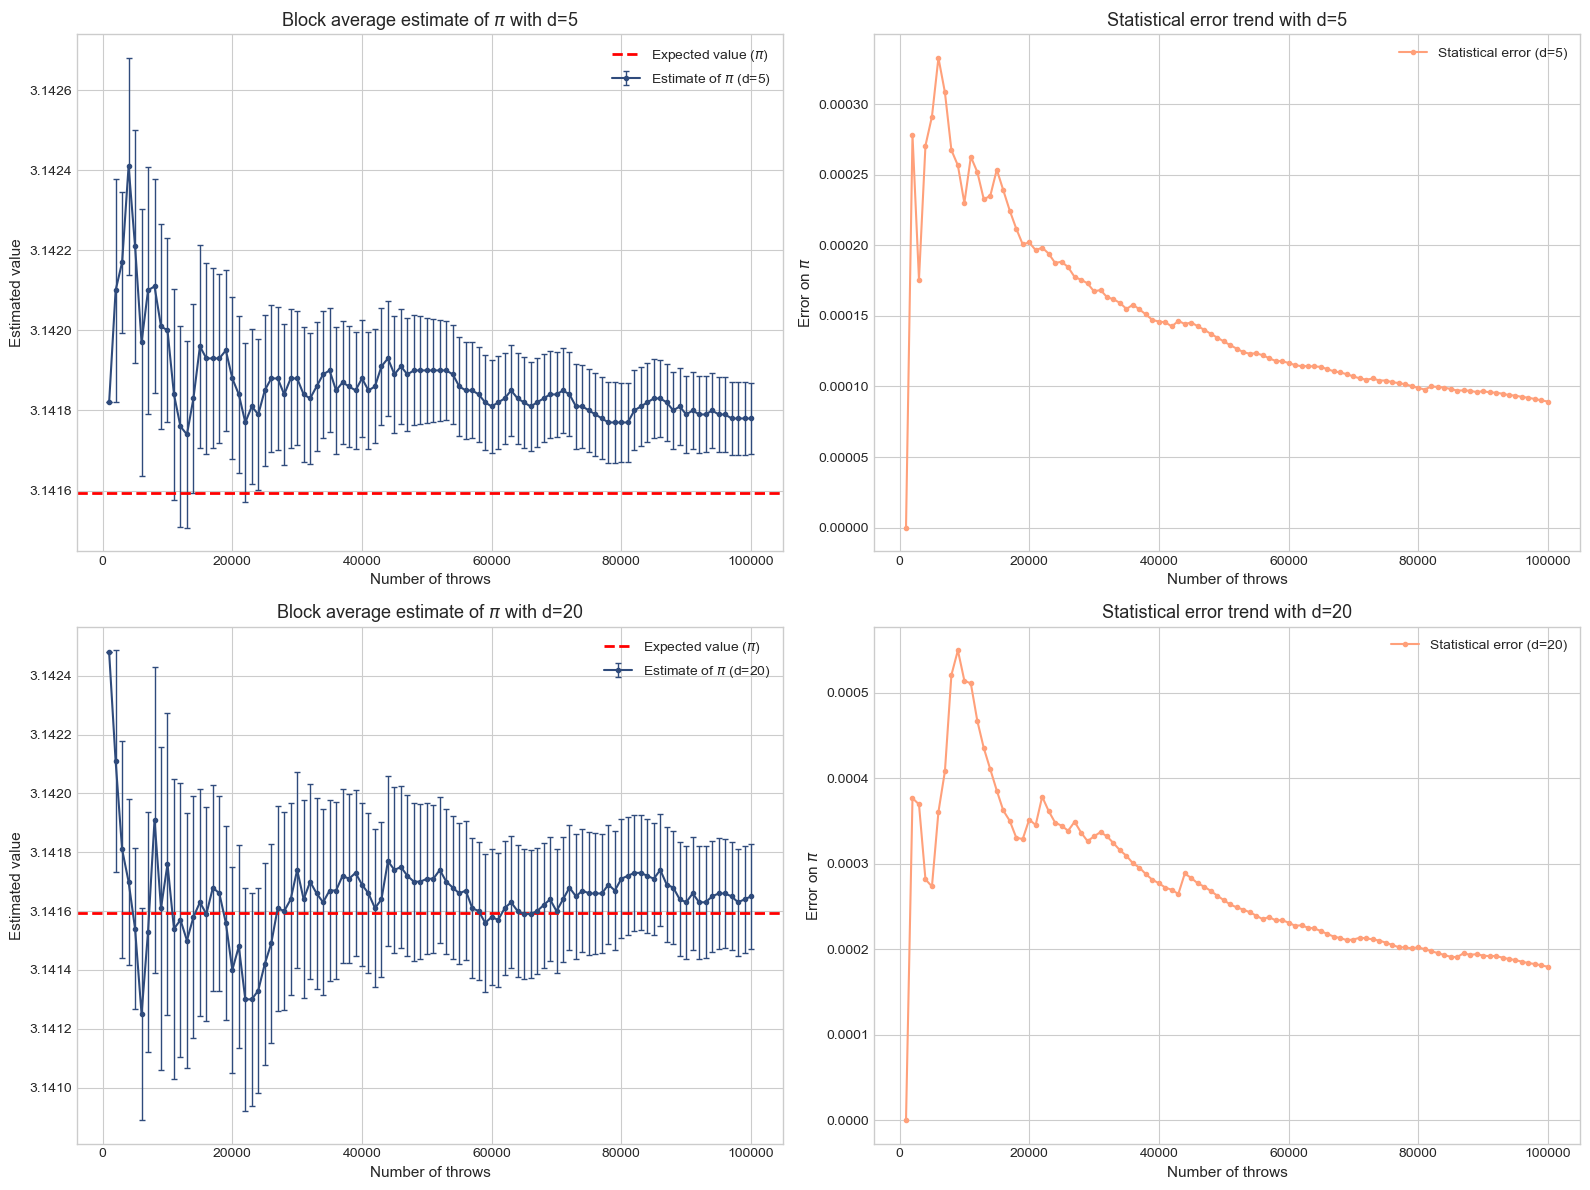

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Ensure the destination folder for the images exists
os.makedirs("ES1.3/IMAGES", exist_ok=True)

# L = number of throws per block (adjust based on your C++ setup)
L = 1000 

# --- Load data for d = 5 ---
x1, f1, error1_data = np.loadtxt(
    "ES1.3/DATA/Buffon_5.dat",
    usecols=(0, 1, 2),
    delimiter='\t',
    unpack=True
)
x1 = x1 * L # X-axis: total number of throws

# --- Load data for d = 20 ---
x2, f2, error2_data = np.loadtxt(
    "ES1.3/DATA/Buffon_20.dat",
    usecols=(0, 1, 2),
    delimiter='\t',
    unpack=True
)
x2 = x2 * L # X-axis: total number of throws

# --- Plot Setup ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# ---------------------------------------------------
# PLOT 1: Estimate of pi (d = 5)
# ---------------------------------------------------
axs[0, 0].errorbar(
    x1, f1, yerr=error1_data,
    fmt='o-', markersize=3,
    capsize=2, elinewidth=1,
    label='Estimate of $\pi$ (d=5)',
    color='#2F4B7C'
)
axs[0, 0].axhline(
    y=np.pi, color='red', linestyle='--', linewidth=2,
    label='Expected value ($\pi$)'
)
axs[0, 0].set_xlabel('Number of throws', fontsize=11)
axs[0, 0].set_ylabel('Estimated value', fontsize=11)
axs[0, 0].set_title('Block average estimate of $\pi$ with d=5', fontsize=13)
axs[0, 0].legend(fontsize=10)

# ---------------------------------------------------
# PLOT 2: Statistical error (d = 5)
# ---------------------------------------------------
axs[0, 1].plot(
    x1, error1_data,
    marker='o', markersize=3, linestyle='-',
    color='#FFA07A', label='Statistical error (d=5)'
)
axs[0, 1].set_xlabel('Number of throws', fontsize=11)
axs[0, 1].set_ylabel('Error on $\pi$', fontsize=11)
axs[0, 1].set_title('Statistical error trend with d=5', fontsize=13)
axs[0, 1].legend(fontsize=10)

# ---------------------------------------------------
# PLOT 3: Estimate of pi (d = 20)
# ---------------------------------------------------
axs[1, 0].errorbar(
    x2, f2, yerr=error2_data,
    fmt='o-', markersize=3,
    capsize=2, elinewidth=1,
    label='Estimate of $\pi$ (d=20)',
    color='#2F4B7C'
)
axs[1, 0].axhline(
    y=np.pi, color='red', linestyle='--', linewidth=2,
    label='Expected value ($\pi$)'
)
axs[1, 0].set_xlabel('Number of throws', fontsize=11)
axs[1, 0].set_ylabel('Estimated value', fontsize=11)
axs[1, 0].set_title('Block average estimate of $\pi$ with d=20', fontsize=13)
axs[1, 0].legend(fontsize=10)

# ---------------------------------------------------
# PLOT 4: Statistical error (d = 20)
# ---------------------------------------------------
axs[1, 1].plot(
    x2, error2_data,
    marker='o', markersize=3, linestyle='-',
    color='#FFA07A', label='Statistical error (d=20)'
)
axs[1, 1].set_xlabel('Number of throws', fontsize=11)
axs[1, 1].set_ylabel('Error on $\pi$', fontsize=11)
axs[1, 1].set_title('Statistical error trend with d=20', fontsize=13)
axs[1, 1].legend(fontsize=10)

# Space optimization and saving
plt.tight_layout()
plt.savefig("ES1.3/IMAGES/buffon_combined_results.jpg", dpi=300)
plt.show()

The first and second plot are executed for $N_{experiments}$ = $10^5$, $N_{tries}$ = $10^5$ and $N_{blocks}$ = $100$ with $d$ = 5 and $d$ = 20. From the plots we can see clearly that the value of the block average tends to the $\pi$ and on the other hand it is possible to see the power law descent of the error. The block average done on all blocks with its relative error (which is the standard deviation of the mean) appear to be compatible with the expected value $\pi$.